4. What is the most optimal skill to learn for Data Analyst? (High Demand AND High Paying)

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

In [2]:
#Load Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [3]:
#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [7]:
#Narrow Data to Malaysia & Singapore Data Analyst
df_da_my_sg = df[(df['job_title_short'] == 'Data Analyst') & ((df['job_country'] == 'Malaysia') | (df['job_country'] == 'Singapore'))].copy()

#drop null salary
df_da_my_sg = df_da_my_sg.dropna(subset=['salary_year_avg'])

df_da_my_sg_explode = df_da_my_sg.explode('job_skills')

In [10]:
df_da_skills = df_da_my_sg_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values('count', ascending = False)
df_da_skills = df_da_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

#Total count of data analyst job
da_jobs_count = len(df_da_my_sg)

df_da_skills['skill_percent'] = df_da_skills['skill_count']/da_jobs_count*100
df_da_skills=df_da_skills[df_da_skills['skill_count']>0]
df_da_skills


,skill_count,median_salary,skill_percent
job_skills,,,
sql,21,98500.0,53.846154
python,17,100500.0,43.589744
tableau,14,99500.0,35.897436
excel,13,100500.0,33.333333
r,8,93852.0,20.512821
spark,6,130414.0,15.384615
power bi,5,75000.0,12.820513
aws,5,100500.0,12.820513
flow,5,105000.0,12.820513


In [11]:
#Assume skills with >10% as high demand
skill_limit = 10
df_da_skills_high_demand = df_da_skills[df_da_skills['skill_percent'] > skill_limit]

([Text(54.85350754755997, 99984.3035714286, ' sql'),
  Text(46.34486145574855, 101654.45833333334, ' python'),
  Text(39.045278897849464, 99659.69047619047, ' tableau'),
  Text(35.103617400744405, 102479.07142857145, ' excel'),
  Text(21.05115604321753, 94841.53571428574, ' r'),
  Text(17.65033731389578, 131568.45833333334, ' spark'),
  Text(16.13148779983457, 76154.45833333334, ' power bi'),
  Text(14.439748759305207, 100335.0773809524, ' aws'),
  Text(14.518293786186927, 106484.30357142858, ' flow'),
  Text(12.727557640612076, 94857.65476190478, ' looker')],
  <matplotlib.patches.FancyArrowPatch at 0x23e1d8c2350>])

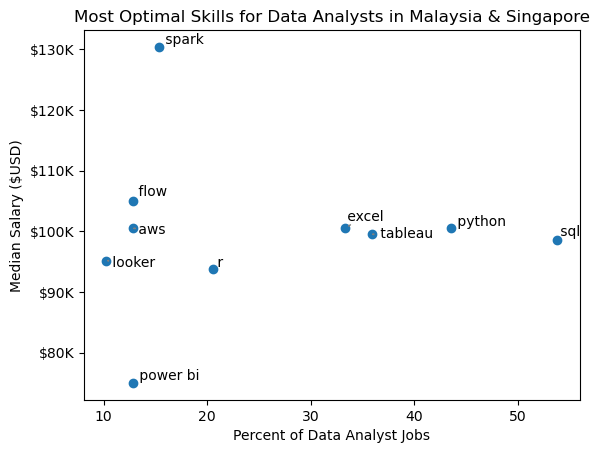

In [13]:
from adjustText import adjust_text

plt.scatter(df_da_skills_high_demand['skill_percent'], df_da_skills_high_demand['median_salary'])
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')
plt.title('Most Optimal Skills for Data Analysts in Malaysia & Singapore')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Example formatting y-axis

# Add labels to points and collect them in a list
texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(plt.text(df_da_skills_high_demand['skill_percent'].iloc[i], df_da_skills_high_demand['median_salary'].iloc[i], " " + txt))

# Adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

color label skills

In [14]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove null values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['sheets',
  'ssrs',
  'dax',
  'splunk',
  'visio',
  'looker',
  'alteryx',
  'esquisse',
  'spss',
  'word',
  'sas',
  'nuix',
  'powerbi',
  'excel',
  'powerpoint',
  'qlik',
  'datarobot',
  'msaccess',
  'tableau',
  'sap',
  'cognos',
  'microstrategy',
  'ms access',
  'outlook',
  'spreadsheet',
  'power bi',
  'sharepoint',
  'ssis'],
 'programming': ['javascript',
  'ocaml',
  'lua',
  'php',
  'python',
  'haskell',
  'css',
  'cobol',
  't-sql',
  'objective-c',
  'powershell',
  'c#',
  'go',
  'typescript',
  'sas',
  'c++',
  'apl',
  'swift',
  'crystal',
  'mongo',
  'rust',
  'pascal',
  'clojure',
  'erlang',
  'sass',
  'java',
  'no-sql',
  'groovy',
  'visual basic',
  'matlab',
  'delphi',
  'scala',
  'dart',
  'julia',
  'nosql',
  'sql',
  'vba',
  'vb.net',
  'elixir',
  'bash',
  'c',
  'kotlin',
  'visualbasic',
  'mongodb',
  'solidity',
  'assembly',
  'lisp',
  'ruby',
  'shell',
  'r',
  'f#',
  'perl',
  'html',
  'fortran',
  'gol

In [16]:
# turn dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])
df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,sheets
0,analyst_tools,ssrs
0,analyst_tools,dax
0,analyst_tools,splunk
0,analyst_tools,visio
...,...,...
9,sync,microsoft teams
9,sync,wire
9,sync,unify
9,sync,slack


In [17]:
# merge df_DA_skills and df_technology
df_da_skills_tech = df_da_skills.merge(df_technology, left_on='job_skills', right_on='skills')
df_da_skills_tech

,skill_count,median_salary,skill_percent,technology,skills
0,21,98500.0,53.846154,programming,sql
1,17,100500.0,43.589744,programming,python
2,14,99500.0,35.897436,analyst_tools,tableau
3,13,100500.0,33.333333,analyst_tools,excel
4,8,93852.0,20.512821,programming,r
5,6,130414.0,15.384615,libraries,spark
6,5,75000.0,12.820513,analyst_tools,power bi
7,5,100500.0,12.820513,cloud,aws
8,5,105000.0,12.820513,other,flow
9,4,95187.5,10.256410,analyst_tools,looker


In [18]:
#Define high demand skills
df_da_skills_tech_high_demand = df_da_skills_tech[df_da_skills_tech['skill_percent'] > skill_limit]

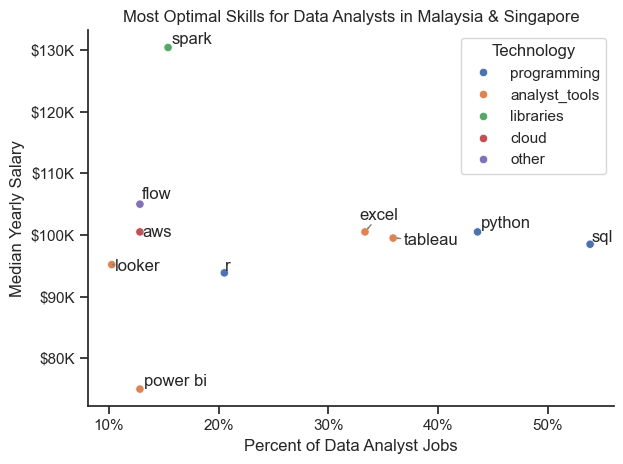

In [21]:
sns.scatterplot(
    data=df_da_skills_tech_high_demand,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(plt.text(df_da_skills_high_demand['skill_percent'].iloc[i], df_da_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in Malaysia & Singapore')
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()